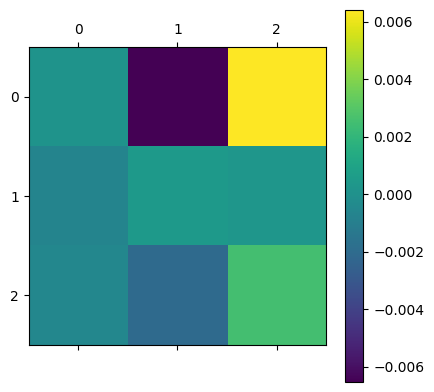

In [ ]:
import matplotlib.pyplot as plt

import torch
from torchvision.io import read_image
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchvision.transforms import Resize, Grayscale

fire = read_image("data/style/good_ones/fire.png")
dark_matter = read_image("data/style/good_ones/dark_matter_bw.png")
starry = read_image("data/style/good_ones/starry.jpg")

fire_vol = read_image("report/fire-broken.jpg")
dark_matter_vol = read_image("report/dark-matter-bw-broken.png")
starry_vol = read_image("report/starry-broken.png")


imgs = [fire, dark_matter, starry]
vols = [fire_vol, dark_matter_vol, starry_vol]
# vols = imgs

lpips_metric = LearnedPerceptualImagePatchSimilarity("alex")
similarities = torch.zeros((len(imgs), len(vols)))

resize = Resize(fire_vol.shape[-2:])
gray = Grayscale(3)


for i,img in enumerate(imgs):
    img = gray(resize(img)).unsqueeze(0).to(torch.float32) / 255
    for j,vol in enumerate(vols):
        vol = gray(resize(vol)).unsqueeze(0).to(torch.float32) / 255
        similarities[i,j] = lpips_metric(img, vol)

# fig = plt.figure()
# ax = fig.add_subplot(111)
# cax = ax.matshow(similarities)
# fig.colorbar(cax)
# ax.

plt.matshow(similarities)
plt.colorbar()
plt.show()

